In [1]:
from pathlib import Path

from prismadv.data_models import ConstraintsWithSources
from prismadv.data_models.config import PrismaDVConfig
from workflow.utils.results_analysis import collect_results
from workflow.utils.results_analysis import format_results_latex, build_confusion_matrices

In [2]:
dataset_name_options = ["students", "hr_analytics", "sleep_health", "IPL_win_prediction", "imdb"]
model_order = ["gpt-5"]
unique_subset_cols = [
    "llm_name", "llm_temperature", "use_async",
    "dataset_name", "subtask_name",
    "processed_data_label", "script_name", "is_clean"
]

In [3]:
def meta_extractor_prismadv(constraint_file: Path, raw: dict) -> dict:
    prismadv_config = PrismaDVConfig.from_dict(raw["prismadv_config"])
    return {
        "llm_name": prismadv_config.llm.model_name,
        "llm_temperature": prismadv_config.llm.temperature,
        "use_async": prismadv_config.model.use_async,
        "timestamp": constraint_file.stem.split("--")[-1],
    }


def constraints_parser_prismadv(raw: dict):
    return ConstraintsWithSources.from_dict({"constraints": raw["constraints"]})


def validation_kwargs_prismadv():
    # supply the toggle used in your original snippet
    return {"constraints_on_single_column_only": False}


df_all_unique = collect_results(
    dataset_name_options=dataset_name_options,
    unique_subset_cols=unique_subset_cols,
    constraint_glob="prismadv--*.yaml",
    row_meta_extractor=meta_extractor_prismadv,
    constraints_parser=constraints_parser_prismadv,
    validation_check_kwargs_fn=validation_kwargs_prismadv,
    model_order=model_order,  # optional filter
)

In [4]:
confusion_matrices_df = build_confusion_matrices(df_all_unique)

In [5]:
latex_output = format_results_latex(
    confusion_matrex_df=confusion_matrices_df,
    dataset_name_options=dataset_name_options,
    model_order=model_order,
    decimals=2,
    model_label_prefix="w/o Post-Processing",
    include_overall=True
)
print(latex_output)

%% === Dataset: students ===
& \texttt{w/o Post-Processing [gpt-5]} & 48.8 & 0.0 & 120 & 11 & 65 & 54 & 68.97\% & 91.60\% & 78.69\% \\
%% === Dataset: hr_analytics ===
& \texttt{w/o Post-Processing [gpt-5]} & 53.3 & 0.0 & 147 & 20 & 72 & 61 & 70.67\% & 88.02\% & 78.40\% \\
%% === Dataset: sleep_health ===
& \texttt{w/o Post-Processing [gpt-5]} & 31.8 & 0.0 & 157 & 16 & 50 & 102 & 60.62\% & 90.75\% & 72.69\% \\
%% === Dataset: IPL_win_prediction ===
& \texttt{w/o Post-Processing [gpt-5]} & 52.5 & 0.0 & 176 & 33 & 127 & 39 & 81.86\% & 84.21\% & 83.02\% \\
%% === Dataset: imdb ===
& \texttt{w/o Post-Processing [gpt-5]} & 36.3 & 0.0 & 115 & 32 & 54 & 49 & 70.12\% & 78.23\% & 73.95\% \\

%% === Overall (All Datasets Combined) ===
& \texttt{w/o Post-Processing [gpt-5]} & 44.5 & 0.0 & 715 & 112 & 368 & 305 & 70.45\% & 86.56\% & 77.35\% \\


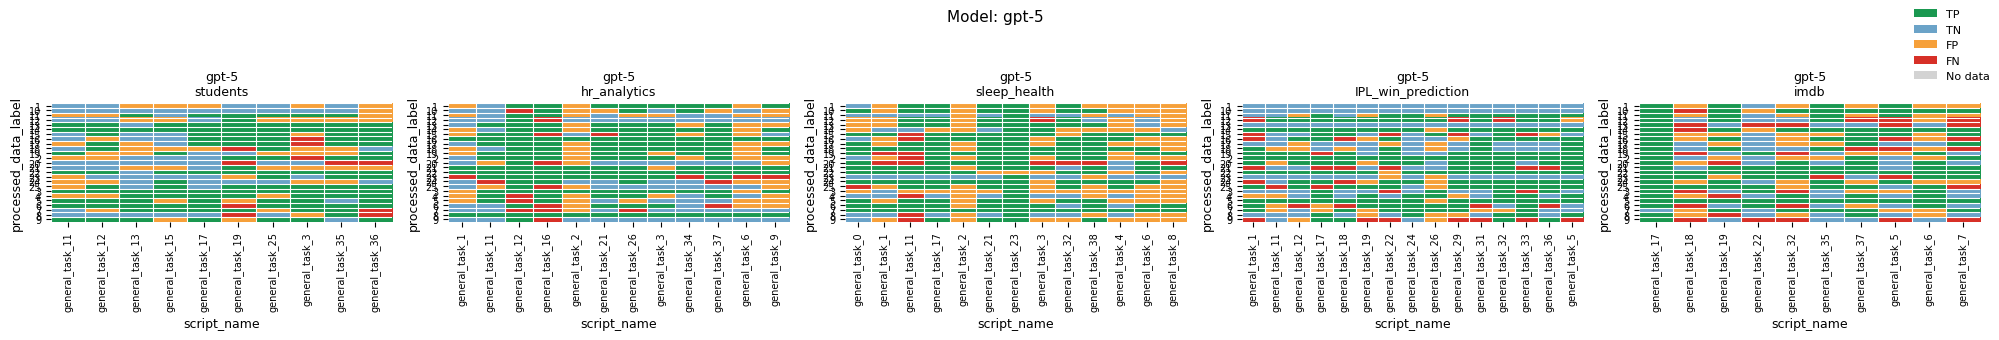

In [6]:
from workflow.utils.results_analysis import build_correct_grids, plot_correct_grids

grids = build_correct_grids(df_all_unique, dataset_name_options, threshold=0.5)
plot_correct_grids(grids, model_order=model_order, dataset_name_options=dataset_name_options)